# Analyse des Résultats de Recherche Évolutionnaire et du Dataset d'Accuracy


In [8]:
# Importer les bibliothèques nécessaires
import json
import os
import matplotlib.pyplot as plt

In [9]:
# Définir les chemins des outputs
output_plots_dir = "./plots"
# Créer le répertoire des plots s'il n'existe pas
os.makedirs(output_plots_dir, exist_ok=True)

## Section 1 : Évolution de la Recherche Évolutionnaire (search_160m)

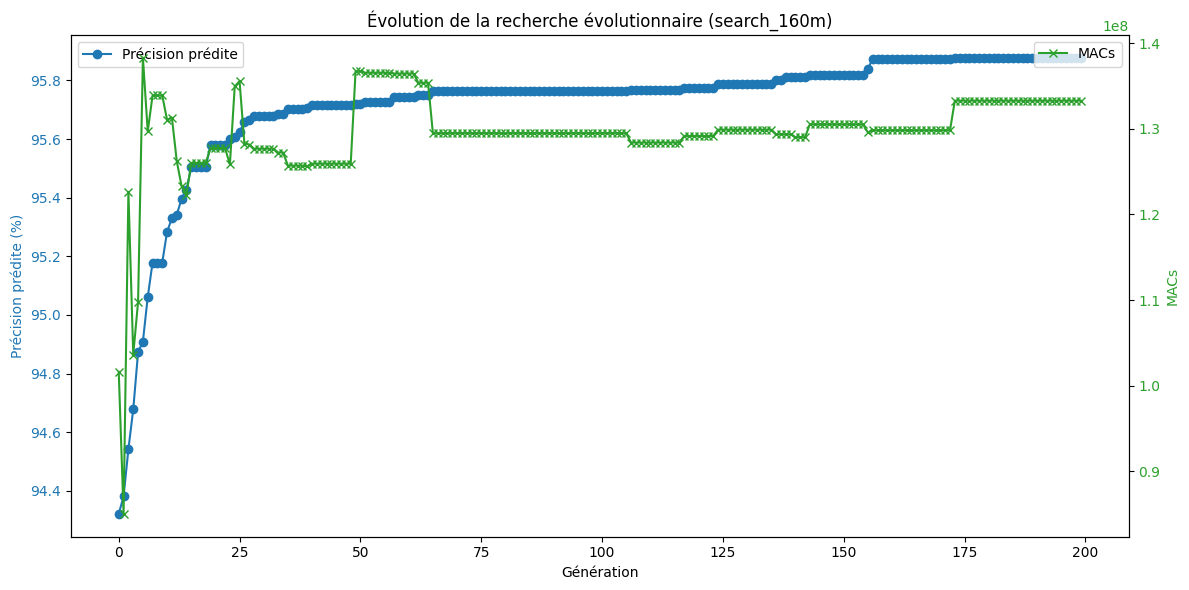

In [10]:
# Définir le nombre de MACs
nombre_macs = 160 # 160M

# Chemin vers le fichier search_history.json pour search_160m
search_history_path = f'./../run/ofa_kernel_transform_10h/search_{nombre_macs}m/search/search_history.json'

# Vérifier si le fichier existe
if not os.path.exists(search_history_path):
    raise FileNotFoundError(f"Le fichier {search_history_path} est introuvable.")

# Charger les données du fichier
with open(search_history_path, 'r') as f:
    search_history = json.load(f)

# Extraire les données pour le plot
generations = []
pred_accs = []
macs_values = []

for generation_idx, generation in enumerate(search_history):
    best = generation.get('best', {})
    pred_acc = best.get('pred_acc')
    macs = best.get('macs')
    if pred_acc is not None and macs is not None:
        generations.append(generation_idx)
        pred_accs.append(pred_acc)
        macs_values.append(macs)

# Création d'une figure avec deux axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Premier axe : Précision prédite
color = 'tab:blue'
ax1.set_xlabel("Génération")
ax1.set_ylabel("Précision prédite (%)", color=color)
ax1.plot(generations, pred_accs, marker='o', label='Précision prédite', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

# Deuxième axe : MACs
ax2 = ax1.twinx()  # Partage le même axe x
color = 'tab:green'
ax2.set_ylabel("MACs", color=color)
ax2.plot(generations, macs_values, marker='x', label='MACs', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

# Titre et mise en page
plt.title(f"Évolution de la recherche évolutionnaire (search_{nombre_macs}m)")
fig.tight_layout()

plt.show()

## Section 2 : Analyse du Dataset d'Accuracy (acc_dataset_30000.jsonl)

In [11]:
# Chemin vers le fichier acc_dataset_30000.jsonl
file_path = './../run/ofa_kernel_transform_10h/acc_dataset_30000.jsonl'

# Charger les données
accs = []
losses = []
macs = []

with open(file_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        accs.append(data['acc'])
        losses.append(data['loss'])
        macs.append(data['macs'])

# Création de la figure
plt.figure(figsize=(12, 6))

# Premier graphique : Précision vs MACs
plt.subplot(1, 2, 1)
plt.scatter(macs, accs, color='blue', alpha=0.7, label='Précision (%)')
plt.title('Précision en fonction des MACs')
plt.xlabel('MACs')
plt.ylabel('Précision (%)')
plt.grid(True)
plt.legend()

# Deuxième graphique : Loss vs MACs
plt.subplot(1, 2, 2)
plt.scatter(macs, losses, color='red', alpha=0.7, label='Loss')
plt.title('Loss en fonction des MACs')
plt.xlabel('MACs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Ajuster la mise en page et sauvegarder
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './../run/ofa_kernel_transform_10h/acc_dataset_30000.jsonl'

### Nouvelle Visualisation : Histogrammes et Analyse des Précisions

Pour mieux comprendre la distribution des précisions pour chaque catégorie de MACs, nous allons utiliser des histogrammes. Ces graphiques permettront de visualiser la répartition des précisions et d'identifier des tendances ou des anomalies.

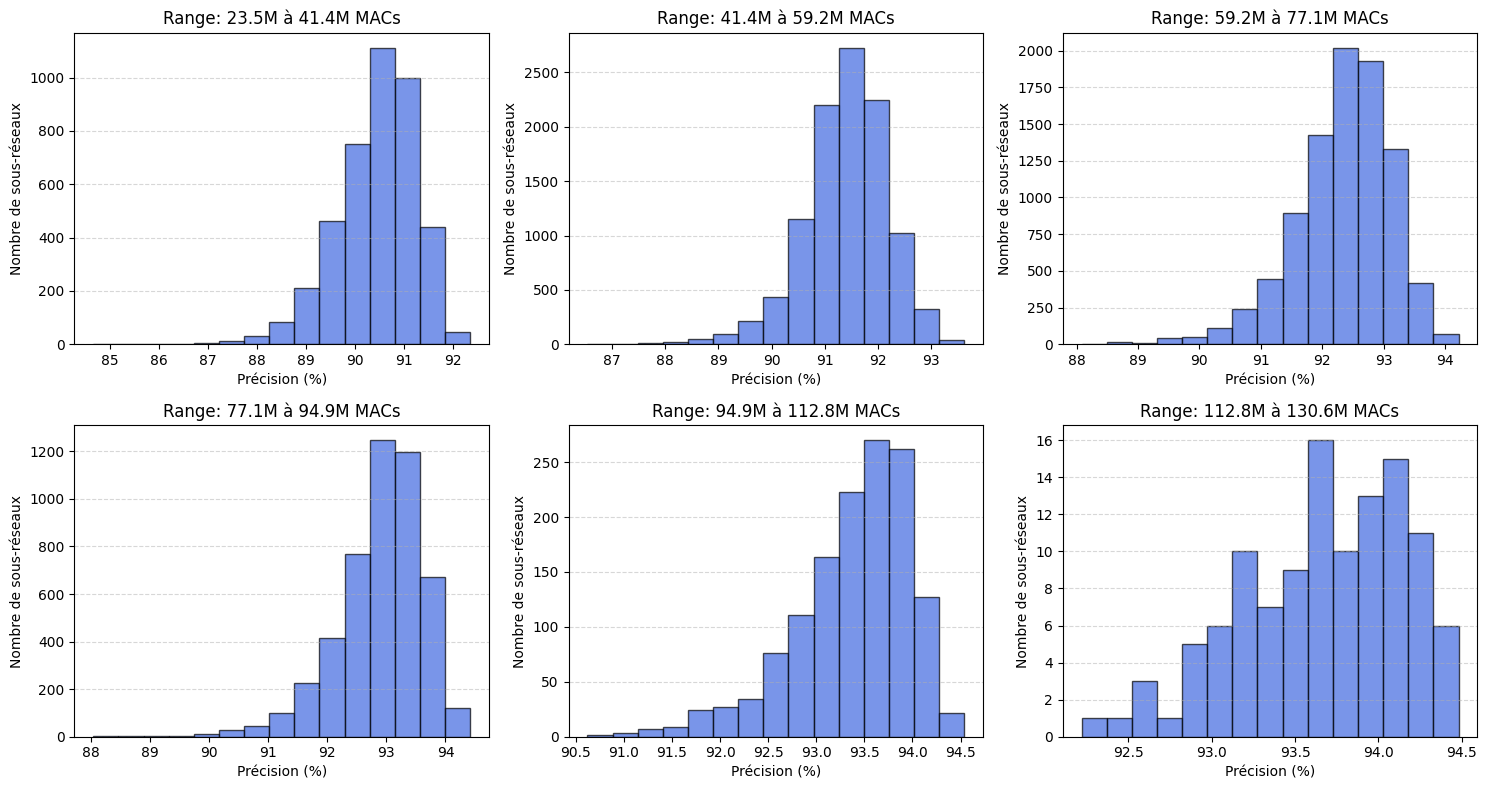

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définir un nombre fixe de catégories (intervalles)
num_bins = 6  # 6 graphiques max, parfait pour une grille 2x3
min_mac = min(macs)
max_mac = max(macs)

# Créer les frontières des intervalles de manière linéaire
bin_edges = np.linspace(min_mac, max_mac, num_bins + 1)

# Préparer le dictionnaire pour regrouper les précisions par index d'intervalle
bin_to_accs = {i: [] for i in range(num_bins)}

for i, mac in enumerate(macs):
    if isinstance(mac, (int, float)) and i < len(accs):
        # np.digitize renvoie l'index de l'intervalle (1-indexed)
        bin_idx = np.digitize(mac, bin_edges) - 1
        # Sécurité pour la valeur maximale absolue
        bin_idx = min(max(0, bin_idx), num_bins - 1)
        bin_to_accs[bin_idx].append(accs[i])

# 2. Générer les histogrammes sur une grille propre
num_cols = 3
num_rows = (num_bins + num_cols - 1) // num_cols

plt.figure(figsize=(15, 4 * num_rows))

for bin_idx in range(num_bins):
    acc_list = bin_to_accs[bin_idx]
    
    if len(acc_list) > 0:
        plt.subplot(num_rows, num_cols, bin_idx + 1)
        
        # Affichage de l'histogramme pour cet intervalle
        plt.hist(acc_list, bins=15, color='royalblue', alpha=0.7, edgecolor='black')
        
        # Calcul des labels des frontières en Millions (M) pour plus de lisibilité
        low_m = bin_edges[bin_idx] / 1e6
        high_m = bin_edges[bin_idx + 1] / 1e6
        
        plt.title(f"Range: {low_m:.1f}M à {high_m:.1f}M MACs")
        plt.xlabel("Précision (%)")
        plt.ylabel("Nombre de sous-réseaux")
        plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig(os.path.join(output_plots_dir, 'acc_histograms_by_mac_bins.png'))
plt.tight_layout()
plt.show()

1. La confirmation de la logique "Plus c'est gros, mieux c'est" (La translation)
C'est le premier constat visuel : la cloche globale se déplace mécaniquement vers la droite à mesure que l'on monte dans les catégories de MACs.

Dans la plage la plus légère (23.5M à 41.4M), le pic (mode) se situe autour de 90,5% de précision.

Dans la plage la plus lourde (112.8M à 130.6M), le pic se déplace au-delà de 93,5%, voire 94%.

Conclusion : Ton supernet a bien appris à tirer profit de la capacité de calcul supplémentaire (plus de canaux, plus de couches, meilleure résolution).

2. La loi des rendements décroissants (Le "Plafond")
Regarde attentivement la précision maximale absolue atteinte dans les trois derniers graphiques (à partir de 77.1M MACs).

Peu importe l'augmentation des MACs (de 77M à 130M), la limite supérieure de précision stagne et semble butter sur un plafond de verre invisible autour de 94,5%.

Conclusion : Pour CIFAR-10 avec cette architecture, doubler le budget de calcul au-delà de 80M MACs n'apporte presque plus aucun gain de performance brute. Le réseau s'approche de sa capacité de saturation sur ce jeu de données.

3. La preuve irréfutable de l'utilité du NAS (La variabilité intra-catégorie)
C'est l'argument majeur en faveur de ton projet de recherche d'architecture (NAS) :

Si tu prends la plage 41.4M à 59.2M MACs, tu as des sous-réseaux médiocres qui tournent à 88% de précision, et d'autres, pour le même coût algorithmique, qui atteignent 93%.

Conclusion : Les MACs ne font pas tout. L'agencement structurel des blocs (le choix minutieux de la profondeur, des noyaux et des expansions au bon endroit) a un impact massif. Trouver ces perles rares à budget égal, c'est précisément le rôle de ta recherche évolutionnaire.

4. Le biais caché de l'échantillonnage (L'observation la plus critique pour ton Master)
Regarde bien l'axe Y (Nombre de sous-réseaux) d'un graphique à l'autre :

Les plages intermédiaires (41.4M à 77.1M) comptent entre 2000 et 2700 sous-réseaux.

La dernière plage (112.8M à 130.6M) culmine à... 16 sous-réseaux !

Pourquoi ce phénomène ? Ton script a généré le jeu de données avec la stratégie uniform. Mathématiquement, la probabilité d'obtenir une architecture "moyenne" (mélange de petits et grands choix) est infiniment plus élevée que celle d'obtenir une architecture extrême (où presque tous les 20 blocs choisiraient l'expansion maximale de 6 et le noyau de 7 simultanément).

Bilan pour ton projet
Ton prédicteur d'exactitude (le MLP) va être extrêmement fort et robuste pour prédire les performances des modèles situés entre 40M et 80M MACs car il a des milliers d'exemples pour s'entraîner. En revanche, il risque d'être beaucoup moins précis (générer plus d'incertitude ou d'erreurs) sur les très gros modèles, faute de données représentatives dans ton fichier JSONL.

Est-ce que cela te donne envie de tester la stratégie large_biased (prévue dans ton code) pour générer quelques milliers de profils lourds supplémentaires et équilibrer l'entraînement de ton prédicteur ?

**Il faudrait le faire pour que le MLP soit plus robuste.**

### Section 3: Comparaison des métriques

Dans cette section, nous allons comparer deux relations importantes :

1. La précision par génération pour chaque catégorie de nombre de MACs.
2. Le nombre de MACs par génération.

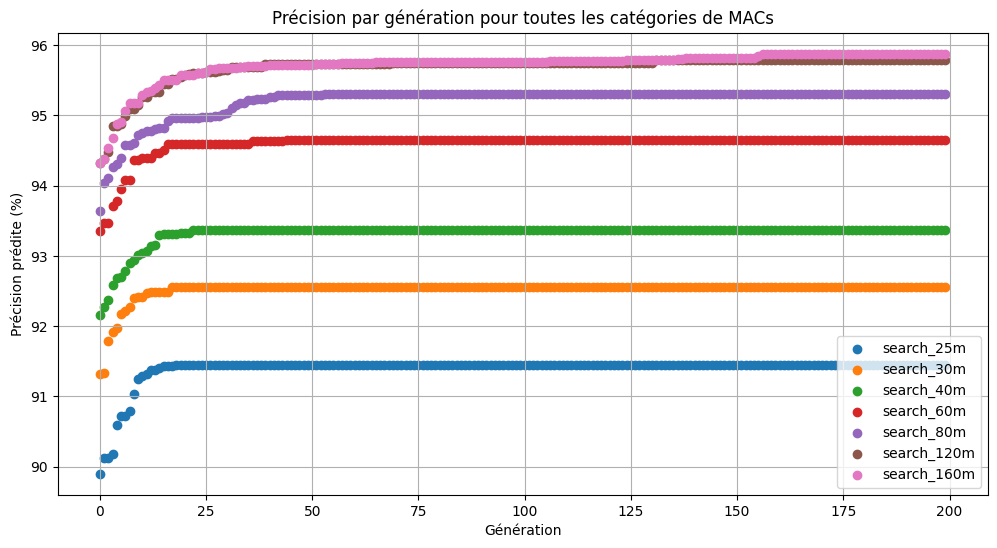

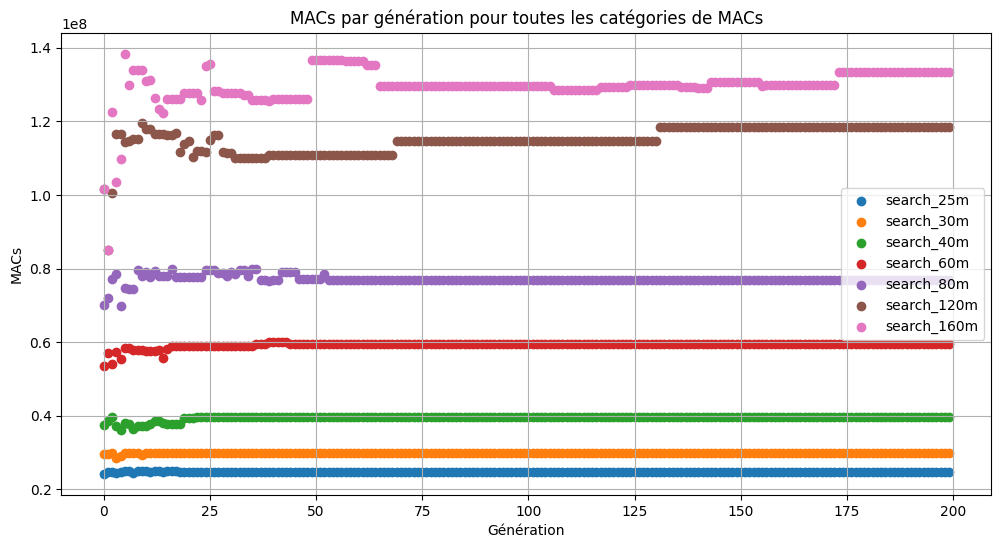

In [ ]:
# Importation des bibliothèques nécessaires
import matplotlib.pyplot as plt
import json
import os
import numpy as np

# Chargement des données pour toutes les catégories de MACs
categories = ["25m", "30m", "40m", "60m", "80m", "120m", "160m"]
all_generations = {}
all_pred_accs = {}
all_macs_values = {}

for category in categories:
    search_history_path = f"./../run/ofa_kernel_transform_10h/search_{category}/search/search_history.json"
    if not os.path.exists(search_history_path):
        print(f"Le fichier {search_history_path} est introuvable.")
        continue

    with open(search_history_path, 'r') as f:
        search_history = json.load(f)

    generations = []
    pred_accs = []
    macs_values = []

    for generation_idx, generation in enumerate(search_history):
        best = generation.get('best', {})
        pred_acc = best.get('pred_acc')
        macs = best.get('macs')
        if pred_acc is not None and macs is not None:
            generations.append(generation_idx)
            pred_accs.append(pred_acc)
            macs_values.append(macs)

    all_generations[category] = generations
    all_pred_accs[category] = pred_accs
    all_macs_values[category] = macs_values

# Fonction pour trouver la génération où le changement devient négligeable
def find_stable_generation(values, threshold):
    diffs = np.abs(np.diff(values))
    for i, diff in enumerate(diffs):
        if diff < threshold:
            return i + 1  # Retourne la génération où le changement devient négligeable
    return len(values) - 1

# Définir les seuils pour précision et MACs
precision_threshold = 0.01  # Seuil pour la précision
macs_threshold = 1e6  # Seuil pour les MACs

# Graphique 1 : Précision par génération pour toutes les catégories de MACs
plt.figure(figsize=(12, 6))
for category in categories:
    if category in all_generations:
        plt.scatter(all_generations[category], all_pred_accs[category], label=f"search_{category}")
        stable_gen = find_stable_generation(all_pred_accs[category], precision_threshold)
        #plt.axvline(x=stable_gen, color='gray', linestyle='--', alpha=0.7, label=f"Stable (search_{category})")
plt.xlabel("Génération")
plt.ylabel("Précision prédite (%)")
plt.title("Précision par génération pour toutes les catégories de MACs")
plt.legend()
plt.grid(True)
plt.show()

# Graphique 2 : MACs par génération pour toutes les catégories de MACs
plt.figure(figsize=(12, 6))
for category in categories:
    if category in all_generations:
        plt.scatter(all_generations[category], all_macs_values[category], label=f"search_{category}")
        stable_gen = find_stable_generation(all_macs_values[category], macs_threshold)
        #plt.axvline(x=stable_gen, color='gray', linestyle='--', alpha=0.7, label=f"Stable (search_{category})")
plt.xlabel("Génération")
plt.ylabel("MACs")
plt.title("MACs par génération pour toutes les catégories de MACs")
plt.legend()
plt.grid(True)
plt.show()

Observations : Les modèles d'une taille donnée convergent vers un seuil de précision. Cette convergence a lieu plus ou moins rapidement en fonction de la taille du modèle(+précis: le nombre de MACs du modèle)

### Trucs intéressants sur la recherche évolutive

1. **C'est un excellent démonstrateur pédagogique, mais biaisé**
   Pour un projet de recherche ou un environnement de test, l'algorithme remplit parfaitement son rôle : il est ultra-rapide (grâce au proxy du prédicteur) et respecte mathématiquement la consigne d'un plafond de MACs. Cependant, il ne faut pas le confondre avec un outil d'optimisation d'efficacité industrielle. C'est un algorithme de maximisation de performance sous contrainte, pas un algorithme de recherche d'efficacité.

2. **Une forte tendance à "l'obésité" des modèles**
   - *Gaspillage de ressources* : L'algorithme sélectionne systématiquement l'architecture la plus lourde possible tant qu'elle ne dépasse pas la limite N d'un cheveu.
   - *Sélection aveugle* : Si un modèle deux fois plus petit (ex: 40% de la limite de MACs) atteint exactement la même précision à 0,05% près, l'algorithme va l'éliminer sans états d'âme au profit du gros modèle à 99% du budget.

3. **Une inefficacité computationnelle en fin de recherche**
   Plus l'algorithme avance dans les générations, plus la population se rapproche de la frontière des MACs autorisés. À ce stade :
   - L'algorithme commence à "tourner à vide" dans sa boucle while.
   - La majorité des mutations positives (qui augmentent les noyaux ou l'expansion) font basculer les enfants au-dessus de la limite, provoquant leur rejet immédiat.
   - On passe beaucoup de temps à générer des architectures candidates pour finalement les jeter à la poubelle avant même de les évaluer.

### Comment corriger cela ?

Pour intégrer l'exploration des modèles plus légers, il faudrait modifier la fonction `score()` pour passer d'une logique de pénalisation brute à une logique de récompense d'efficacité. On peut utiliser une fonction multi-objectif, comme dans les papiers de type MnasNet :

$$
\text{Score(spec)} = \text{Accuracy(spec)} \times [\text{NMACs(spec)}]^\beta
$$

Où $\beta$ est un nombre négatif (par exemple, $\beta = -0.07$). Cette approche garantit que, si deux modèles ont la même précision, celui qui a le moins de MACs obtiendra un meilleur score. Cela force l'algorithme génétique à explorer et à maintenir des gènes de modèles plus petits dans sa population.

#### Points à surveiller :
- **Coût des accès mémoire (Memory Access Cost - MAC)** : Les modèles avec moins de MACs peuvent être plus lents si leurs patterns d'accès mémoire sont inefficaces.
- **Parallélisme matériel** : Les GPUs et TPUs sont optimisés pour des dimensions spécifiques (multiples de 8, 32, 64). Des dimensions non alignées peuvent annuler les gains théoriques.
- **Impact de la résolution vs profondeur** : Réduire la résolution divise les MACs de manière quadratique, mais cela peut nuire à la latence réelle.

### Ajout de la mesure de la latence en fonction des MACs + précision

Il serait pertinent de mesurer la latence des différents sous-réseaux en fonction des MACs et de la précision. Cela permettrait de mieux comprendre les compromis entre efficacité et performance réelle, et d'identifier les architectures optimales pour des contraintes spécifiques.

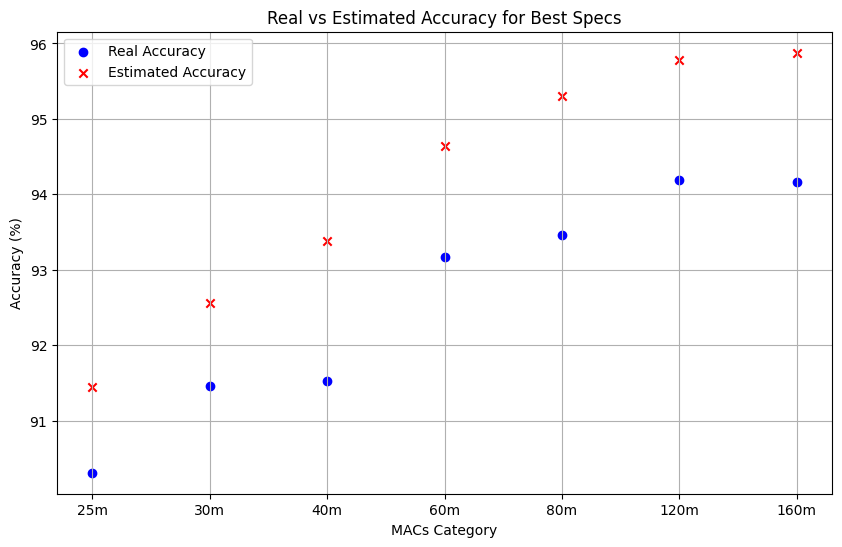

In [ ]:
# Graphique : Best specs par catégorie de MACs, estimated accuracy vs real accuracy
import matplotlib.pyplot as plt
import json
import os
import re

# Define categories
categories = ["25m", "30m", "40m", "60m", "80m", "120m", "160m"]

# Dictionaries to store accuracies
real_accuracies = {}
estimated_accuracies = {}

# Loop through each category to gather data
for category in categories:
    # Path to the log file for real accuracy
    log_path = f"./../run/ofa_kernel_transform_10h/logs/eval_{category}.log"
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            content = f.read()
            # Find the line with "Test accuracy:"
            match = re.search(r"Test accuracy: ([\d.]+)", content)
            if match:
                real_accuracies[category] = float(match.group(1))

    # Path to the json file for estimated accuracy
    json_path = f"./../run/ofa_kernel_transform_10h/search_{category}/search/best_spec.json"
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
            estimated_accuracies[category] = data.get("pred_acc")

# Create the scatter plot
plt.figure(figsize=(10, 6))

# Plot real accuracies
plt.scatter(real_accuracies.keys(), real_accuracies.values(), color='blue', label='Real Accuracy', marker='o')

# Plot estimated accuracies
plt.scatter(estimated_accuracies.keys(), estimated_accuracies.values(), color='red', label='Estimated Accuracy', marker='x')

# Add labels and title
plt.xlabel("MACs Category")
plt.ylabel("Accuracy (%)")
plt.title("Real vs Estimated Accuracy for Best Specs")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

